# Notebook 12 – Feature Relationships

## Introduction

Feature relationships help us understand how input variables interact with each other and with the target variable.

In Machine Learning, feature relationship analysis is important for improving model performance, reducing redundancy, and selecting the most useful features.

### Topics Covered

1. Correlation Matrix
2. Multicollinearity
3. Variance Inflation Factor (VIF)
4. Feature Importance
5. Feature Selection Basics

## 1. Correlation Matrix

### Definition

A correlation matrix is a table that shows the correlation coefficient between every pair of numerical features.

The values range from **-1 to +1**.

- +1 → Perfect positive correlation
- -1 → Perfect negative correlation
- 0 → No linear correlation

### Business Example

A bank checks the relationship between customer income, loan amount, and credit score.

### AI/ML Example

It helps identify highly correlated features before training a model.

### Interpretation

Highly correlated features may contain similar information.

In [1]:
import pandas as pd

data = pd.DataFrame({
    "Age":[25,30,35,40,45],
    "Income":[30000,40000,50000,60000,70000],
    "Loan":[100000,120000,150000,180000,200000]
})

corr = data.corr()

print(corr)

             Age    Income      Loan
Age     1.000000  1.000000  0.997054
Income  1.000000  1.000000  0.997054
Loan    0.997054  0.997054  1.000000


## 2. Multicollinearity

### Definition

Multicollinearity occurs when two or more independent features are highly correlated with each other.

This creates redundant information in the dataset.

### Why It Is a Problem

- Unstable coefficients
- Difficult feature interpretation
- Reduced reliability in linear models

### Business Example

Income and annual salary may provide almost the same information.

### AI/ML Example

Linear Regression is more affected by multicollinearity than many tree-based models.

### Interpretation

If features are highly correlated, consider removing one or combining them.

## 3. Variance Inflation Factor (VIF)

### Definition

VIF measures how much multicollinearity exists in a feature.

### Formula

VIF = 1 / (1 − R²)

### Interpretation

- VIF = 1 → No multicollinearity
- VIF 1–5 → Moderate
- VIF > 5 → High
- VIF > 10 → Very High

### Business Example

A company checks whether Income and Salary are redundant.

### AI/ML Example

VIF is commonly used before Linear Regression.

In [6]:
X = pd.DataFrame({
    "Age": [25, 30, 35, 40, 45],
    "Income": [30, 42, 49, 63, 68],
    "Salary": [35, 45, 55, 60, 72]
})

## 4. Feature Importance

### Definition

Feature importance tells us which features contribute the most to a machine learning model's prediction.

Higher importance means the feature has greater influence.

### Business Example

In house price prediction, square feet may be more important than house color.

### AI/ML Example

Random Forest automatically calculates feature importance.

### Interpretation

Important features help improve model performance and explain predictions.

In [7]:
from sklearn.ensemble import RandomForestRegressor
import pandas as pd

X = pd.DataFrame({
    "Area":[1000,1200,1500,1800,2000],
    "Bedrooms":[2,2,3,3,4],
    "Age":[20,15,10,8,5]
})

y = [40,50,65,80,95]

model = RandomForestRegressor(random_state=42)
model.fit(X,y)

importance = pd.DataFrame({
    "Feature":X.columns,
    "Importance":model.feature_importances_
})

print(importance)

    Feature  Importance
0      Area    0.389546
1  Bedrooms    0.298188
2       Age    0.312266


## 5. Feature Selection Basics

### Definition

Feature selection is the process of choosing the most useful features for model training.

### Why It Is Important

- Improves accuracy
- Reduces overfitting
- Faster training
- Simpler models

### Types

1. Filter Method
2. Wrapper Method
3. Embedded Method

### Business Example

A bank selects only relevant customer attributes for loan approval.

### AI/ML Example

Removing unnecessary features improves model efficiency.

### Interpretation

Good feature selection removes redundant and irrelevant variables.

In [8]:
from sklearn.feature_selection import SelectKBest, f_regression
import pandas as pd

X = pd.DataFrame({
    "Area":[1000,1200,1500,1800,2000],
    "Bedrooms":[2,2,3,3,4],
    "Age":[20,15,10,8,5]
})

y = [40,50,65,80,95]

selector = SelectKBest(score_func=f_regression, k=2)
selector.fit(X,y)

selected = X.columns[selector.get_support()]

print("Selected Features:", list(selected))

Selected Features: ['Area', 'Age']


## Heatmap

A heatmap is a visual representation of the correlation matrix.

Dark colors represent stronger correlations.

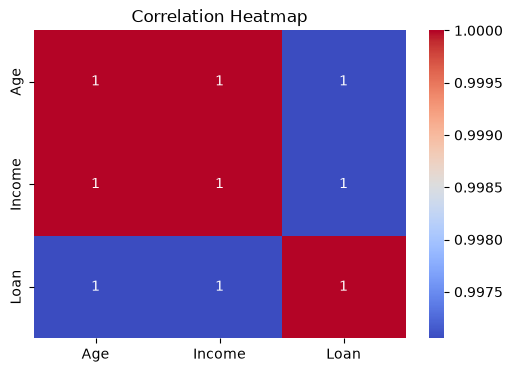

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# Summary

| Concept | Purpose |
|---------|---------|
| Correlation Matrix | Relationship between features |
| Multicollinearity | Detect highly correlated features |
| VIF | Measure multicollinearity |
| Feature Importance | Identify influential features |
| Feature Selection | Choose useful features |